# 只有入流和出流区域单车骑行记录的终点与起始点距离城市中心的距离差
统计只有出流和入流区域的单车骑行记录，然后分别计算骑行终点及起始点的区域距离城市中心的距离后求两者的差，并观察其分布

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
cen_x=[121.492494]   #城市中心坐标
cen_y=[31.225719]

In [4]:
df=pd.read_csv('df.csv')   #筛选数据后的单车数据
df

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,2.727397
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,3.013957
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,2.972972
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,3.661382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,3.176235
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,0.844479
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,2.999509
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,3.842861


In [5]:
sid=(np.load("500m起始区域id(bj).npy")).tolist()
sid1=pd.Series(sid)
eid=(np.load("500m终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [6]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [7]:
s_eid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(a)
    c.append(b)
    s_eid.append(c)

In [8]:
for i in range(0,len(s_eid)):
    hr=s_eid[i]
    s_eid[i]=str(hr)

In [9]:
s_eid1=pd.Series(s_eid)
s_eid1

0             [941, 9347]
1          [50459, 47949]
2           [4148, 58023]
3           [9126, 19416]
4           [6347, 23909]
                ...      
3094262     [7521, 22824]
3094263    [10753, 54699]
3094264    [14429, 14445]
3094265     [3574, 11820]
3094266    [57346, 62927]
Length: 3094267, dtype: object

In [10]:
df["s_eid"]=s_eid1

In [11]:
e_sid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(b)
    c.append(a)
    e_sid.append(c)

In [35]:
for i in range(0,len(e_sid)):
    hr=e_sid[i]
    e_sid[i]=str(hr)

In [36]:
e_sid1=pd.Series(e_sid)
e_sid1

0             [9347, 941]
1          [47949, 50459]
2           [58023, 4148]
3           [19416, 9126]
4           [23909, 6347]
                ...      
3094262     [22824, 7521]
3094263    [54699, 10753]
3094264    [14445, 14429]
3094265     [11820, 3574]
3094266    [62927, 57346]
Length: 3094267, dtype: object

In [37]:
df["e_sid"]=e_sid1

In [38]:
df1_1=df[df["sid"]!=-1]

In [39]:
df1_2=df1_1[df1_1["eid"]!=-1]

In [40]:
df10=df1_2[df1_2["sid"]!=df1_2["eid"]]      #不在同一区域内的数据
df10

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed,sid,eid,s_eid,e_sid
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,2.727397,941,9347,"[941, 9347]","[9347, 941]"
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,3.013957,50459,47949,"[50459, 47949]","[47949, 50459]"
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963,4148,58023,"[4148, 58023]","[58023, 4148]"
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,2.972972,9126,19416,"[9126, 19416]","[19416, 9126]"
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,3.661382,6347,23909,"[6347, 23909]","[23909, 6347]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,3.176235,7521,22824,"[7521, 22824]","[22824, 7521]"
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,0.844479,10753,54699,"[10753, 54699]","[54699, 10753]"
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,2.999509,14429,14445,"[14429, 14445]","[14445, 14429]"
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,3.842861,3574,11820,"[3574, 11820]","[11820, 3574]"


In [41]:
loca1=(df1_2["sid"]).tolist()
loca2=(df1_2["eid"]).tolist()

In [42]:
local3=[]           #统计所有的区域
local3.extend(loca1)     
local3.extend(loca2)

In [43]:
local3=pd.Series(local3)

In [44]:
diff_loca=local3.value_counts()

In [45]:
diff_loca1=(diff_loca.index).tolist()  
diff_loca1    #所有不同区域

[64727,
 57310,
 64922,
 56328,
 181,
 49515,
 48636,
 8396,
 56642,
 64795,
 7114,
 56606,
 21429,
 994,
 51352,
 16583,
 9732,
 61559,
 64687,
 52397,
 827,
 63477,
 4708,
 13192,
 2696,
 14782,
 7160,
 58506,
 2267,
 511,
 28679,
 59280,
 15445,
 27185,
 16607,
 50599,
 11508,
 54137,
 9585,
 2598,
 8822,
 194,
 63198,
 18246,
 18737,
 59120,
 64037,
 49825,
 66582,
 56712,
 49754,
 2271,
 3424,
 44692,
 11885,
 17402,
 13171,
 56707,
 1042,
 2955,
 23427,
 18964,
 2964,
 33563,
 64879,
 65518,
 17509,
 58831,
 7324,
 11177,
 5468,
 8089,
 61562,
 20090,
 155,
 55235,
 44123,
 36788,
 7357,
 25955,
 65530,
 1444,
 22181,
 4420,
 5527,
 59909,
 11089,
 2632,
 20663,
 62305,
 21824,
 8931,
 10795,
 22474,
 5004,
 63926,
 6509,
 50633,
 597,
 12787,
 55829,
 904,
 7719,
 5992,
 38764,
 59322,
 62461,
 17829,
 1823,
 47772,
 2576,
 54647,
 29207,
 62364,
 9713,
 28325,
 18552,
 20574,
 10154,
 65156,
 50,
 20981,
 273,
 19592,
 4687,
 2260,
 66047,
 19378,
 8357,
 19460,
 18538,
 13494,

In [46]:
df8_1=df1_2[df1_2["sid"]==df1_2["eid"]]      #在同一区域内的数据
df8_1

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed,sid,eid,s_eid,e_sid
6,495333,185893,67441,1,2017-05-14 22:16:53,wx4emgw,wx4emgk,116.277237,39.966202,116.274490,39.964828,1,126,2.218662,17297,17297,"[17297, 17297]","[17297, 17297]"
17,1119812,72084,137713,2,2017-05-14 22:16:58,wx4f6s6,wx4f6s1,116.480484,39.794540,116.479111,39.793167,1,63,3.056071,66145,66145,"[66145, 66145]","[66145, 66145]"
19,1745122,647684,196465,2,2017-05-14 22:17:00,wx4g323,wx4g328,116.424179,39.948349,116.422806,39.949722,1,164,1.172994,1029,1029,"[1029, 1029]","[1029, 1029]"
64,1927777,753891,213795,2,2017-05-14 22:17:21,wx4gkju,wx4gkn5,116.549149,39.978561,116.547775,39.979935,1,311,0.618906,9654,9654,"[9654, 9654]","[9654, 9654]"
72,764025,852654,101207,1,2017-05-14 22:17:23,wx4fc0c,wx4fc02,116.413193,39.863205,116.411819,39.860458,1,138,2.370955,53402,53402,"[53402, 53402]","[53402, 53402]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094219,1675977,986520,189813,2,2017-05-23 06:20:39,wx4g4sd,wx4g4s4,116.480484,39.927750,116.480484,39.925003,1,88,3.471051,13159,13159,"[13159, 13159]","[13159, 13159]"
3094232,3451860,120784,356447,1,2017-05-23 06:20:40,wx4g4fv,wx4g4fq,116.495590,39.918137,116.496964,39.915390,1,97,3.372764,5004,5004,"[5004, 5004]","[5004, 5004]"
3094249,2821294,736434,297275,2,2017-05-23 06:20:44,wx4fcp1,wx4fcnf,116.413193,39.897537,116.414566,39.896164,1,115,1.673264,4471,4471,"[4471, 4471]","[4471, 4471]"
3094253,3971890,376406,406493,1,2017-05-23 06:20:49,wx4f6vd,wx4f6tx,116.491470,39.801407,116.487350,39.801407,1,96,3.666263,47989,47989,"[47989, 47989]","[47989, 47989]"


In [47]:
same_loca=df8_1["sid"].value_counts()
same_loca

52397    1361
58506    1120
48636     875
64922     637
65518     582
         ... 
10065       1
20060       1
1621        1
53254       1
25011       1
Name: sid, Length: 7422, dtype: int64

In [48]:
same_loca1=(same_loca.index).tolist()#有内环流量的区域
same_loca1

[52397,
 58506,
 48636,
 64922,
 65518,
 11508,
 9940,
 904,
 63198,
 56642,
 18246,
 1042,
 56328,
 50599,
 59909,
 54137,
 61562,
 23413,
 45766,
 60807,
 11782,
 37984,
 13192,
 11457,
 64037,
 2696,
 66582,
 8931,
 50638,
 61430,
 181,
 21273,
 2964,
 57310,
 3424,
 8357,
 65377,
 22384,
 65530,
 11177,
 994,
 19359,
 967,
 40836,
 56206,
 58001,
 64727,
 6660,
 63477,
 1210,
 4708,
 27185,
 597,
 55829,
 21644,
 405,
 24007,
 21429,
 11961,
 1444,
 58838,
 56712,
 16199,
 61418,
 511,
 44692,
 65156,
 18344,
 18319,
 9732,
 13171,
 50459,
 8396,
 12062,
 8706,
 1649,
 57354,
 17635,
 44521,
 11128,
 64879,
 63019,
 61981,
 25955,
 19378,
 9341,
 51352,
 515,
 12361,
 54647,
 62305,
 3800,
 53402,
 61559,
 18247,
 14480,
 17402,
 20090,
 25957,
 2738,
 11608,
 59120,
 5992,
 59408,
 64156,
 4678,
 2343,
 65143,
 17829,
 55302,
 12307,
 16583,
 61264,
 10638,
 7160,
 7802,
 58327,
 9278,
 2650,
 60057,
 36788,
 14684,
 19117,
 3888,
 49515,
 49754,
 827,
 52223,
 1385,
 23308,
 8375

In [49]:
unsame_loca=[]
for i in range(0,len(diff_loca1)):
    loci=diff_loca1[i]
    p=loci in same_loca1                   #判断是否是包含自流量的区域
    if(p==False):                          #不包含自流量区域
        unsame_loca.append(loci)

In [50]:
num_1=0                                             #空
num_2=0                                             #无出有进
num_3=0                                             #有出无进
num_4=0                                             #有出有进
lis1=[]
lis2=[]
lis3=[]
lis4=[]
for i in range(0,len(unsame_loca)):
    z=unsame_loca[i]
    dtf1=df1_2[df1_2["sid"]==z]    
    dtf1_1=dtf1[dtf1["sid"]!=dtf1["eid"]]
    l1=len(dtf1_1)
    
    dtf2=df1_2[df1_2["eid"]==z]
    dtf2_1=dtf2[dtf2["sid"]!=dtf2["eid"]]
    l2=len(dtf2_1)
    if(l1==0):
        if(l2==0):
            num_1=num_1+1      #数目
            lis1.append(z)
        else:
            num_2=num_2+1  
            lis2.append(z)
    else:
        if(l2==0):
            num_3=num_3+1      #数目
            lis3.append(z)
        else:
            num_4=num_4+1  
            lis4.append(z)     

In [52]:
dfR2 = pd.read_csv("500popdata_bj.csv")      #包含区域人口数据
dfR2

,OBJECTID,Id,Shape_Length,Shape_Area,x,y,OBJECTID_1,Id_1,COUNT,AREA,SUM
0,1,1,429.039265,5038.229607,117.287788,40.660110,1,1,1,6.944440e-07,0.176861
1,2,2,2000.000000,250000.000000,117.219658,40.637150,2,2,39,2.708330e-05,6.566072
2,3,3,2000.000000,250000.000000,116.406105,40.115814,3,3,36,2.500000e-05,3066.989456
3,4,4,2000.000000,250000.000000,116.558075,39.670311,4,4,39,2.708330e-05,294.448074
4,5,5,2000.000000,250000.000000,116.881973,40.199058,5,5,36,2.500000e-05,99.206474
...,...,...,...,...,...,...,...,...,...,...,...
66611,66612,66612,2000.000000,250000.000000,115.868393,39.889046,66289,66612,35,2.430560e-05,10.857436
66612,66613,66613,2000.000000,250000.000000,115.907280,39.747780,66290,66613,40,2.777780e-05,74.296542
66613,66614,66614,2000.000000,250000.000000,116.470535,39.798256,66291,66614,36,2.500000e-05,1435.749268
66614,66615,66615,2000.000000,250000.000000,115.858429,39.578114,66292,66615,36,2.500000e-05,161.408242


In [53]:
x=(dfR2.x).tolist()
y=(dfR2.y).tolist()

In [54]:
i_d=(dfR2.Id).tolist()

In [55]:
xy=[]
for i in range(0,len(x)):
    l=[]
    a=x[i]
    b=y[i]
    l.append(a)
    l.append(b)
    xy.append(l)

In [56]:
b = dict(zip(i_d,xy))

In [57]:
s=[]   #只出
e=[]
for temp in lis3:
    dr=df1_2[df1_2["sid"]==temp]
    x_y1=b[temp]     #起始经纬
    s.append(x_y1)
    
    x_1=x_y1[0]   #经度
    y_1=x_y1[1]   #纬度
    
    Ti=len(dr)    
    e_id=(dr["eid"].value_counts().index).tolist()
    Tij=(dr["eid"].value_counts().values).tolist()
    
    Pij=[]    #归一化
    for i in range(0,len(Tij)):
        pij=Tij[i]/Ti
        Pij.append(pij)
    sub_x=0
    sub_y=0
    for i in range(0,len(e_id)):
        x_y2=b[e_id[i]]
        x_2=x_y2[0]
        y_2=x_y2[1]
        xpart=(x_2-x_1)*Pij[i]
        ypart=(y_2-y_1)*Pij[i]
        sub_x+=xpart
        sub_y+=ypart
    x_11=x_1+sub_x    # 合成后的坐标
    y_11=y_1+sub_y
    xyl=[]
    xyl.append(x_11)
    xyl.append(y_11)
    e.append(xyl)
    

In [58]:
sud1=[]
for i in range(0,len(s)):
    z=s[i]
    #a=b_b[z]
    x0=z[0]
    y0=z[1]
    ds= get_distance_hav(y0,x0,39.91667,116.41667) #终点到城市中心的距离
    z1=e[i]
        
    #b=b_b[z1_]
    x1=z1[0]
    y1=z1[1]
    de= get_distance_hav(y1,x1,39.91667,116.41667) #起始点到城市中心的距离
    sub_d=de-ds
    sud1.append(sub_d)

In [59]:
for i in range(0,len(sud1)):
    sud1[i]=round(sud1[i],1)

In [60]:
sud1_=pd.Series(sud1)
sud1_1=sud1_.value_counts()

In [61]:
in2=sud1_1.index
va2=sud1_1.values

In [62]:
#np.save('bj只出in2',in2)
#np.save('bj只出va2',va2)

In [ ]:
#in2=np.load('bj只出in2.npy').tolist()
#va2=np.load('bj只出va2.npy').tolist()

In [63]:
s=[]    #只进
e=[]
for temp in lis2:
    dr=df1_2[df1_2["eid"]==temp]
    x_y1=b[temp]     
    s.append(x_y1)
    
    x_1=x_y1[0]   #经度
    y_1=x_y1[1]   #纬度
    
    Ti=len(dr)    
    s_id=(dr["sid"].value_counts().index).tolist()
    Tij=(dr["sid"].value_counts().values).tolist()
    
    Pij=[]    #归一化
    for i in range(0,len(Tij)):
        pij=Tij[i]/Ti
        Pij.append(pij)
    sub_x=0
    sub_y=0
    for i in range(0,len(s_id)):
        x_y2=b[s_id[i]]
        x_2=x_y2[0]
        y_2=x_y2[1]
        xpart=(x_2-x_1)*Pij[i]
        ypart=(y_2-y_1)*Pij[i]
        sub_x+=xpart
        sub_y+=ypart
    x_11=x_1+sub_x    # 合成后的坐标
    y_11=y_1+sub_y
    xyl=[]
    xyl.append(x_11)
    xyl.append(y_11)
    e.append(xyl)
    

In [64]:
sud=[]
for i in range(0,len(s)):
    z=s[i]
    #a=b_b[z]
    x0=z[0]
    y0=z[1]
    de= get_distance_hav(y0,x0,39.91667,116.41667) #终点到城市中心的距离
    z1=e[i]        
    #b=b_b[z1_]
    x1=z1[0]
    y1=z1[1]
    ds= get_distance_hav(y1,x1,39.91667,116.41667) #起始点到城市中心的距离
    sub_d=de-ds
    sud.append(sub_d)

In [65]:
for i in range(0,len(sud)):
    sud[i]=round(sud[i],1)

In [66]:
sud_=pd.Series(sud)
sud_1=sud_.value_counts()

In [67]:
in1=sud_1.index
va1=sud_1.values

In [68]:
#np.save('bj只进in1',in1)
#np.save('bj只进va1',va1)

In [ ]:
#in1=np.load('bj只进in1.npy').tolist()
#va1=np.load('bj只进va1.npy').tolist()

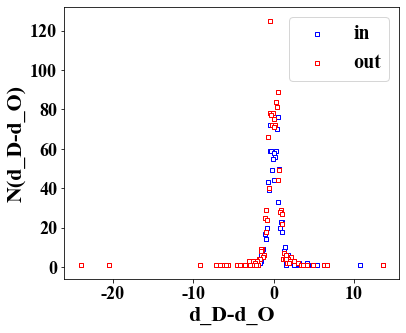

In [69]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
plt.scatter(in1,va1,marker = 's',color="w",linewidths=1,s=20,edgecolors='blue',label="in")
plt.scatter(in2,va2,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="out")

#plt.scatter(popnu,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="Tin",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
plt.legend(loc="best",prop={"family" : "Times New Roman",'size':20})
#ax.set_yscale("log")
#ax.set_xscale("log")
#plt.xlim(10^0,10^10)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("N(d_D-d_O)",size=22,family='Times New Roman')  
ax.set_xlabel("d_D-d_O",size=22,family='Times New Roman')
plt.tick_params(labelsize=18)
#plt.savefig('只进只出区域出发点终点距市中心的距离差.pdf')